# 가전 동작 상태 EDA — sub-state 라벨링 기준 수립

| 항목 | 내용 |
|------|------|
| 목적 | 켜짐 구간의 `active_power`, `power_factor`, `current` 분포를 시각화 + PLAID 상태 레퍼런스 오버레이로 임계값 초안 도출 |
| 대상 가전 | 에어컨, 선풍기, 전자레인지, 헤어드라이기 (PLAID 참고 가능 4종) |
| 데이터 | GCS `ax-nilm-data-dhwang0803-us` 30Hz 한국 데이터 |
| PLAID 통계 | 로컬에서 사전 계산 후 상수로 임베드 (110V → W/PF 직접 비교 가능, I_mean은 ÷2 보정) |
| 참고 | `docs/state_labeling_plan.md` |

In [1]:
!pip install -q gcsfs pyarrow scipy

In [2]:
from google.colab import auth
auth.authenticate_user()
print('GCP 인증 완료')

GCP 인증 완료


In [3]:
import gcsfs
import pandas as pd
import numpy as np
import pyarrow.dataset as ds
import pyarrow.parquet as pq
import pyarrow as pa
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib as mpl
from scipy.signal import find_peaks
import warnings, os, shutil, glob, subprocess
warnings.filterwarnings('ignore')

gcs = gcsfs.GCSFileSystem()

# 한글 폰트 설치
subprocess.run(['apt-get', 'install', '-y', 'fonts-nanum'], capture_output=True)

# 폰트 파일 경로 직접 탐색 → addfont로 명시 등록 (캐시 우회)
ttf_candidates = glob.glob('/usr/share/fonts/**/*Nanum*Gothic*.ttf', recursive=True)
if ttf_candidates:
    fm.fontManager.addfont(ttf_candidates[0])
    prop = fm.FontProperties(fname=ttf_candidates[0])
    font_name = prop.get_name()
    plt.rcParams['font.family'] = font_name
    print(f'폰트 설정: {font_name}  ({ttf_candidates[0]})')
else:
    print('NanumGothic.ttf 파일 없음 — 설치 실패 가능성')
plt.rcParams['axes.unicode_minus'] = False

print('GCS 연결 완료')

폰트 설정: NanumBarunGothic  (/usr/share/fonts/truetype/nanum/NanumBarunGothicBold.ttf)
GCS 연결 완료


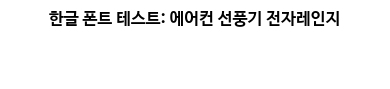

In [4]:
# 한글 폰트 렌더링 확인 — 아래 그래프 제목이 한글로 보이면 OK
fig, ax = plt.subplots(figsize=(4, 1))
ax.set_title('한글 폰트 테스트: 에어컨 선풍기 전자레인지')
ax.axis('off')
plt.tight_layout()
plt.show()

## PLAID 상태별 통계 (로컬 사전 계산 — 110V 기준)

- `W_mean`: 한국 데이터와 직접 비교 가능 (유효전력은 전압 무관)
- `PF_mean`: 직접 비교 가능 (부하 특성값)
- `I_mean`: 한국 데이터는 약 ÷2 수준 (220V → 같은 W에서 전류 절반)

> ⚠️ 에어컨 W_std가 매우 크고 highcool(93W) ≈ lowcool(90W) — W 단독 구분 불가, PF 차이(0.78 vs 0.76)로 보조 구분

In [5]:
# PLAID 상태별 통계 (6170903/ 로컬 데이터 기반 사전 계산)
PLAID_STATS = {
    'Air Conditioner': {
        'highcool': {'W_mean': 93.05,  'PF_mean': 0.781, 'I_mean': 1.118, 'n': 39},
        'highfan':  {'W_mean': 35.76,  'PF_mean': 0.806, 'I_mean': 0.378, 'n': 34},
        'lowcool':  {'W_mean': 90.40,  'PF_mean': 0.755, 'I_mean': 1.180, 'n': 35},
        'lowfan':   {'W_mean': 29.90,  'PF_mean': 0.829, 'I_mean': 0.312, 'n': 34},
    },
    'Fan': {
        'high':   {'W_mean': 32.49, 'PF_mean': 0.770, 'I_mean': 0.357, 'n': 35},
        'medium': {'W_mean': 29.80, 'PF_mean': 0.776, 'I_mean': 0.315, 'n': 30},
        'low':    {'W_mean': 23.18, 'PF_mean': 0.757, 'I_mean': 0.249, 'n': 30},
    },
    'Microwave': {
        'high':    {'W_mean': 228.06, 'PF_mean': 0.559, 'I_mean': 3.475, 'n': 26},
        'medium':  {'W_mean': 210.15, 'PF_mean': 0.533, 'I_mean': 3.375, 'n': 44},
        'regular': {'W_mean': 220.60, 'PF_mean': 0.479, 'I_mean': 3.740, 'n': 20},
    },
    'Hairdryer': {
        'highhot':   {'W_mean': 580.62, 'PF_mean': 0.871, 'I_mean': 5.837, 'n': 20},
        'highwarm':  {'W_mean': 385.97, 'PF_mean': 0.878, 'I_mean': 3.806, 'n':  5},
        'highheat':  {'W_mean': 220.15, 'PF_mean': 0.790, 'I_mean': 2.447, 'n':  6},
        'highcool':  {'W_mean':  92.29, 'PF_mean': 0.859, 'I_mean': 0.919, 'n': 10},
        'mediumhot': {'W_mean': 262.43, 'PF_mean': 0.854, 'I_mean': 2.650, 'n':  5},
        'lowhot':    {'W_mean': 176.51, 'PF_mean': 0.828, 'I_mean': 1.837, 'n': 20},
        'lowwarm':   {'W_mean': 179.79, 'PF_mean': 0.809, 'I_mean': 1.901, 'n':  5},
        'lowheat':   {'W_mean': 125.81, 'PF_mean': 0.794, 'I_mean': 1.381, 'n':  6},
        'lowcool':   {'W_mean':  74.31, 'PF_mean': 0.897, 'I_mean': 0.704, 'n': 10},
        'noheat':    {'W_mean':  22.34, 'PF_mean': 0.770, 'I_mean': 0.251, 'n':  5},
    },
}

# 한국 가전명 → PLAID 가전명 매핑
KR_TO_PLAID = {
    '에어컨':     'Air Conditioner',
    '선풍기':     'Fan',
    '전자레인지': 'Microwave',
    '헤어드라이기': 'Hairdryer',
}

# 상태별 색상
STATE_COLORS = [
    '#e41a1c','#377eb8','#4daf4a','#984ea3','#ff7f00',
    '#a65628','#f781bf','#999999','#66c2a5','#fc8d62',
]

print('PLAID 통계 로드 완료')

PLAID 통계 로드 완료


In [6]:
BUCKET_PREFIX = 'ax-nilm-data-dhwang0803-us/nilm/training_dev10'
LABEL_PATH    = 'ax-nilm-data-dhwang0803-us/nilm/labels/training.parquet'

TARGET_APPLIANCES = ['에어컨', '선풍기', '전자레인지', '헤어드라이기']

EDA_HOUSES = [
    'house_011', 'house_015', 'house_016', 'house_017',
    'house_033', 'house_039', 'house_049', 'house_054',
    'house_063', 'house_067'
]

## 1. 라벨 파일에서 가전별 가구/채널 목록 조회

In [7]:
pa_fs = pa.fs.PyFileSystem(pa.fs.FSSpecHandler(gcs))
labels_df = pq.read_table(LABEL_PATH, filesystem=pa_fs).to_pandas()

print('라벨 컬럼:', labels_df.columns.tolist())
print('총 레코드:', len(labels_df))
labels_df.head(3)

라벨 컬럼: ['household_id', 'channel', 'date', 'appliance_type', 'appliance_name', 'brand', 'start_ts', 'end_ts']
총 레코드: 465001


,household_id,channel,date,appliance_type,appliance_name,brand,start_ts,end_ts
0,house_001,ch01,20230928,main power,메인 분전반,메인 분전반,2023-09-28,2023-09-28 23:59:59.967
1,house_001,ch01,20230922,main power,메인 분전반,메인 분전반,2023-09-22,2023-09-22 23:59:59.967
2,house_001,ch01,20230923,main power,메인 분전반,메인 분전반,2023-09-23,2023-09-23 23:59:59.967


In [8]:
appliance_map = {}  # appliance_name → [(house_id, channel), ...]

for app in TARGET_APPLIANCES:
    rows = labels_df[
        labels_df['appliance_name'].str.contains(app, na=False) &
        labels_df['household_id'].isin(EDA_HOUSES)
    ][['household_id', 'channel']].drop_duplicates()
    appliance_map[app] = list(rows.itertuples(index=False, name=None))
    print(f'{app}: {len(appliance_map[app])}개 채널 → {appliance_map[app]}')

에어컨: 9개 채널 → [('house_011', 'ch13'), ('house_015', 'ch13'), ('house_017', 'ch13'), ('house_033', 'ch13'), ('house_039', 'ch13'), ('house_049', 'ch13'), ('house_054', 'ch13'), ('house_063', 'ch13'), ('house_067', 'ch13')]
선풍기: 10개 채널 → [('house_011', 'ch03'), ('house_015', 'ch03'), ('house_016', 'ch03'), ('house_017', 'ch03'), ('house_033', 'ch03'), ('house_039', 'ch03'), ('house_049', 'ch03'), ('house_054', 'ch03'), ('house_063', 'ch03'), ('house_067', 'ch03')]
전자레인지: 9개 채널 → [('house_011', 'ch09'), ('house_015', 'ch09'), ('house_016', 'ch09'), ('house_017', 'ch09'), ('house_033', 'ch09'), ('house_049', 'ch09'), ('house_054', 'ch09'), ('house_063', 'ch09'), ('house_067', 'ch09')]
헤어드라이기: 9개 채널 → [('house_011', 'ch07'), ('house_015', 'ch07'), ('house_016', 'ch07'), ('house_033', 'ch07'), ('house_039', 'ch07'), ('house_049', 'ch07'), ('house_054', 'ch07'), ('house_063', 'ch07'), ('house_067', 'ch07')]


In [9]:
def get_on_periods(house_id, channel):
    """라벨에서 (start_ts, end_ts) 켜짐 구간 리스트 반환."""
    rows = labels_df[
        (labels_df['household_id'] == house_id) &
        (labels_df['channel'] == channel)
    ]
    periods = []
    for _, row in rows.iterrows():
        s = pd.to_datetime(row.get('start_ts'))
        e = pd.to_datetime(row.get('end_ts'))
        if pd.notna(s) and pd.notna(e):
            periods.append((s, e))
    return periods


def extract_on_data(house_id, channel):
    """켜짐 구간 날짜 파티션만 GCS에서 읽어 on 구간 필터링.
    전체 채널 로드 대신 on 구간 날짜만 로드해 GCS I/O 최소화.
    """
    periods = get_on_periods(house_id, channel)
    if not periods:
        print(f'  [{house_id}/{channel}] 켜짐 구간 없음')
        return pd.DataFrame()

    # on 구간에 해당하는 날짜(YYYYMMDD) 집합
    on_dates = set()
    for s, e in periods:
        d = s.normalize()
        while d <= e.normalize():
            on_dates.add(int(d.strftime('%Y%m%d')))
            d += pd.Timedelta(days=1)

    # PyArrow predicate로 해당 날짜 파티션만 로드
    path = f'{BUCKET_PREFIX}/household_id={house_id}/channel={channel}'
    dataset = ds.dataset(path, filesystem=pa_fs, partitioning='hive')
    date_filter = ds.field('date').isin(list(on_dates))
    table = dataset.to_table(
        columns=['date_time', 'active_power', 'current', 'power_factor',
                 'apparent_power', 'reactive_power'],
        filter=date_filter
    )
    raw = table.to_pandas()
    raw['date_time'] = pd.to_datetime(raw['date_time'])
    raw = raw.sort_values('date_time').reset_index(drop=True)

    # 정확한 on 구간만 필터
    mask = pd.Series(False, index=raw.index)
    for s, e in periods:
        mask |= (raw['date_time'] >= s) & (raw['date_time'] <= e)

    on_df = raw[mask].copy()
    on_df['house_channel'] = f'{house_id}/{channel}'
    print(f'  [{house_id}/{channel}] 로드 날짜: {len(on_dates)}일 | 켜짐 샘플: {len(on_df):,}개 ({len(periods)}구간)')
    return on_df

print('함수 정의 완료')

함수 정의 완료


## 2. 켜짐 구간 raw 데이터 추출

In [10]:
def load_raw_channel(house_id, channel):
    path = f'{BUCKET_PREFIX}/household_id={house_id}/channel={channel}'
    dataset = ds.dataset(path, filesystem=pa_fs, partitioning='hive')
    df = dataset.to_table(
        columns=['date_time', 'active_power', 'current', 'power_factor', 'apparent_power', 'reactive_power']
    ).to_pandas()
    # timezone-naive UTC로 통일 (KST naive와 UTC naive 혼재 방지)
    df['date_time'] = pd.to_datetime(df['date_time']).dt.tz_localize(None)
    return df.sort_values('date_time').reset_index(drop=True)


def get_on_periods(house_id, channel):
    rows = labels_df[
        (labels_df['household_id'] == house_id) &
        (labels_df['channel'] == channel)
    ]
    periods = []
    for _, row in rows.iterrows():
        s = pd.to_datetime(row.get('start_ts'))
        e = pd.to_datetime(row.get('end_ts'))
        if pd.notna(s) and pd.notna(e):
            # tz-aware면 UTC로 변환 후 naive로; naive면 그대로
            s = s.tz_convert('UTC').tz_localize(None) if s.tzinfo else s
            e = e.tz_convert('UTC').tz_localize(None) if e.tzinfo else e
            periods.append((s, e))
    return periods


def extract_on_data(house_id, channel):
    raw = load_raw_channel(house_id, channel)
    periods = get_on_periods(house_id, channel)
    if not periods:
        return pd.DataFrame()
    mask = pd.Series(False, index=raw.index)
    for s, e in periods:
        mask |= (raw['date_time'] >= s) & (raw['date_time'] <= e)
    on_df = raw[mask].copy()
    on_df['house_channel'] = f'{house_id}/{channel}'
    n_matched = mask.sum()
    print(f'  [{house_id}/{channel}] 켜짐 샘플: {n_matched:,}개 ({len(periods)}구간) | mean W={on_df["active_power"].mean():.1f}')
    return on_df

print('함수 정의 완료')

함수 정의 완료


## 3. 가전별 켜짐 구간 데이터 수집

In [11]:
on_data = {}

for app, channels in appliance_map.items():
    if not channels:
        print(f'[{app}] 데이터 없음, 스킵')
        continue
    print(f'\n[{app}] 수집 중...')
    frames = [extract_on_data(h, ch) for h, ch in channels]
    frames = [f for f in frames if not f.empty]
    if frames:
        on_data[app] = pd.concat(frames, ignore_index=True)
        print(f'  → 합계: {len(on_data[app]):,}개 샘플')

print('\n수집 완료')


[에어컨] 수집 중...
  [house_011/ch13] 켜짐 샘플: 1,090,182개 (8구간) | mean W=20.5
  [house_015/ch13] 켜짐 샘플: 2,985,969개 (12구간) | mean W=29.9
  [house_017/ch13] 켜짐 샘플: 1,409,983개 (6구간) | mean W=15.5
  [house_033/ch13] 켜짐 샘플: 966,952개 (10구간) | mean W=67.4
  [house_039/ch13] 켜짐 샘플: 2,721,800개 (7구간) | mean W=13.5
  [house_049/ch13] 켜짐 샘플: 1,996,169개 (6구간) | mean W=23.0
  [house_054/ch13] 켜짐 샘플: 1,017,244개 (4구간) | mean W=26.8
  [house_063/ch13] 켜짐 샘플: 1,986,562개 (8구간) | mean W=25.4
  [house_067/ch13] 켜짐 샘플: 9,637,672개 (5구간) | mean W=18.7
  → 합계: 23,812,533개 샘플

[선풍기] 수집 중...
  [house_011/ch03] 켜짐 샘플: 9,941,964개 (61구간) | mean W=21.4
  [house_015/ch03] 켜짐 샘플: 2,373,248개 (20구간) | mean W=35.0
  [house_016/ch03] 켜짐 샘플: 21,581,906개 (142구간) | mean W=26.2
  [house_017/ch03] 켜짐 샘플: 2,107,834개 (18구간) | mean W=19.8
  [house_033/ch03] 켜짐 샘플: 6,864,931개 (131구간) | mean W=31.3
  [house_039/ch03] 켜짐 샘플: 2,205,044개 (10구간) | mean W=30.9
  [house_049/ch03] 켜짐 샘플: 7,691,131개 (78구간) | mean W=36.7
  [house_054/ch03] 켜짐 샘플:

In [12]:
# 채널 품질 진단 — 가전별 최소 기대 전력 미달 채널 식별
POWER_MIN_THRESH = {
    '에어컨':      25.0,   # lowfan(30W)의 80%
    '선풍기':      15.0,   # Fan low(23W)의 65%
    '전자레인지': 100.0,   # Microwave 최저(210W)의 50%
    '헤어드라이기': 15.0,  # noheat(22W)의 65%
}

bad_channels = {}
for app, df in on_data.items():
    thresh = POWER_MIN_THRESH.get(app, 0)
    per_ch = (
        df.groupby('house_channel')['active_power']
        .agg(mean='mean', median='median', n='count')
        .reset_index()
    )
    per_ch['ok'] = per_ch['mean'] >= thresh
    bad = per_ch[~per_ch['ok']]
    bad_channels[app] = bad['house_channel'].tolist()

    print(f'\n[{app}] 채널별 mean active_power (임계값 ≥{thresh}W)')
    print(per_ch.to_string(index=False))
    if not bad.empty:
        print(f'  ⚠️  품질 미달 채널: {bad["house_channel"].tolist()}')


[에어컨] 채널별 mean active_power (임계값 ≥25.0W)
 house_channel      mean    median       n    ok
house_011/ch13 20.535662 24.219999 1090182 False
house_015/ch13 29.898365  6.090000 2985969  True
house_017/ch13 15.481849 21.520000 1409983 False
house_033/ch13 67.441940 23.840000  966952  True
house_039/ch13 13.511510 16.820000 2721800 False
house_049/ch13 22.955362 23.250000 1996169 False
house_054/ch13 26.810177 15.240000 1017244  True
house_063/ch13 25.414871 25.790001 1986562  True
house_067/ch13 18.702198 16.510000 9637672 False
  ⚠️  품질 미달 채널: ['house_011/ch13', 'house_017/ch13', 'house_039/ch13', 'house_049/ch13', 'house_067/ch13']

[선풍기] 채널별 mean active_power (임계값 ≥15.0W)
 house_channel      mean    median        n   ok
house_011/ch03 21.446268 21.049999  9941960 True
house_015/ch03 35.006828 35.029999  2373248 True
house_016/ch03 26.218458 26.219999 21581906 True
house_017/ch03 19.822601 19.879999  2107834 True
house_033/ch03 31.302731 30.959999  6864931 True
house_039/ch03 30.890068 

## 4. 히스토그램 + PLAID 상태 레퍼런스 오버레이

- **세로 실선**: PLAID 각 상태의 W_mean / PF_mean (한국 데이터와 직접 비교)
- 한국 데이터 군집이 PLAID 레퍼런스 선과 겹치는 위치 → 해당 상태로 라벨링 후보

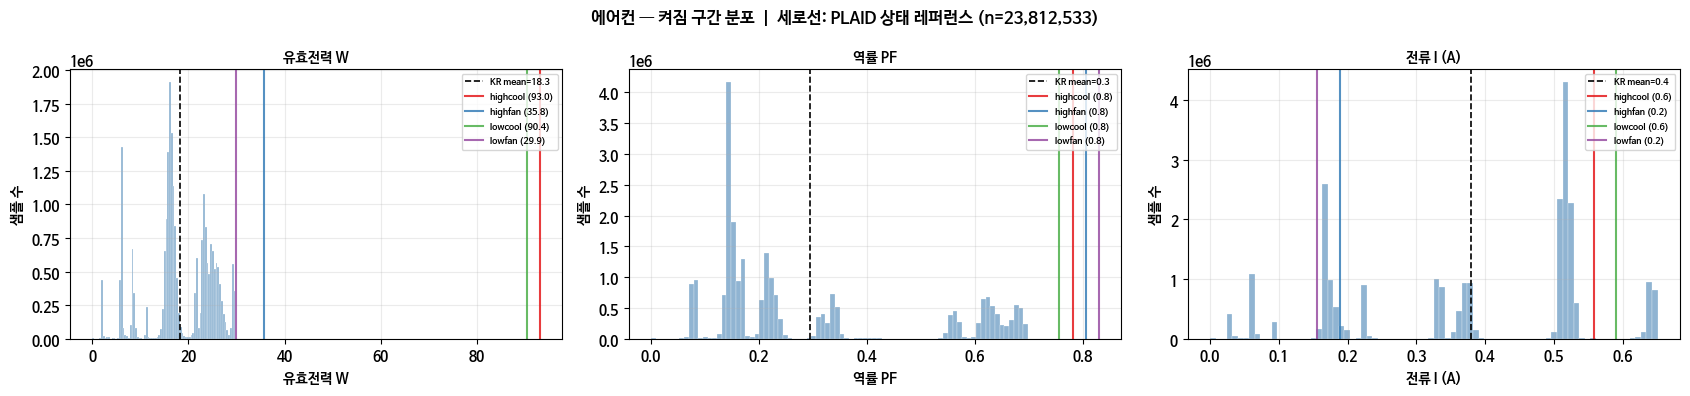

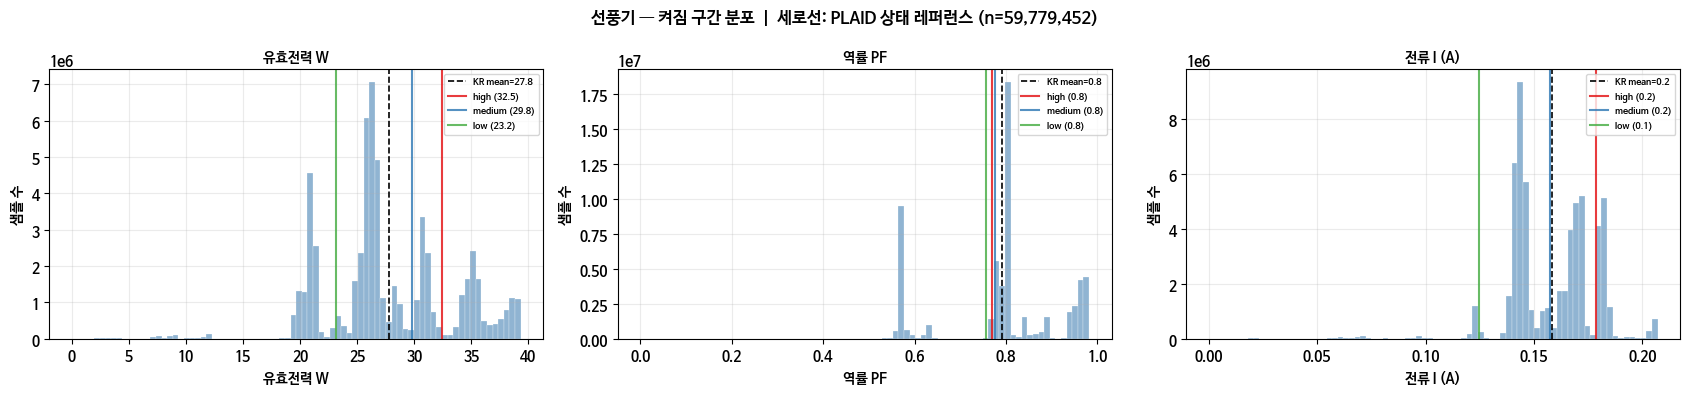

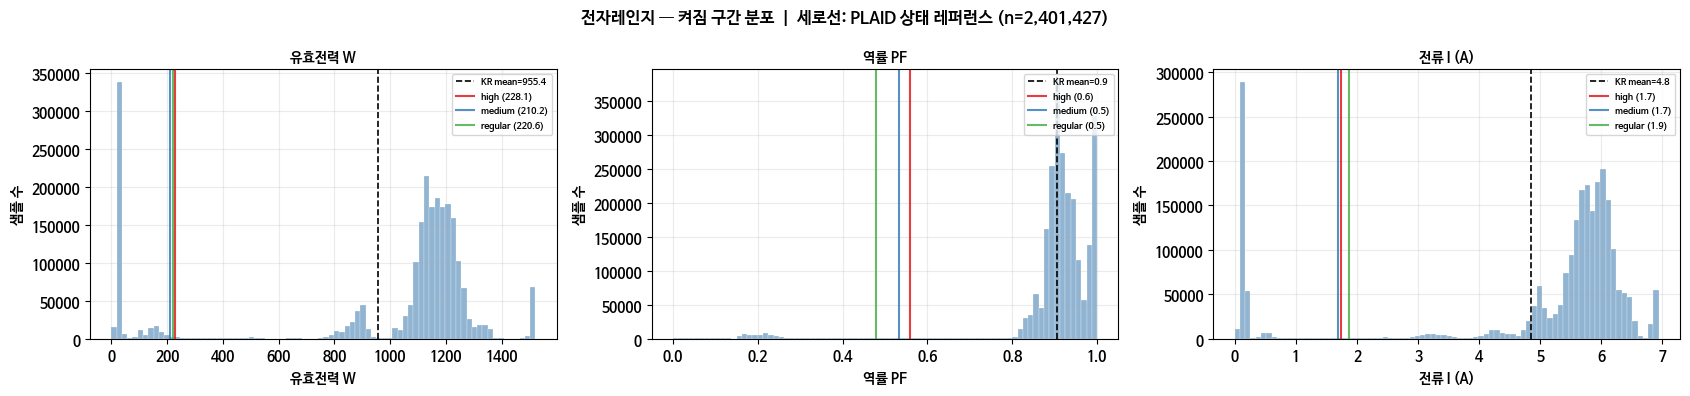

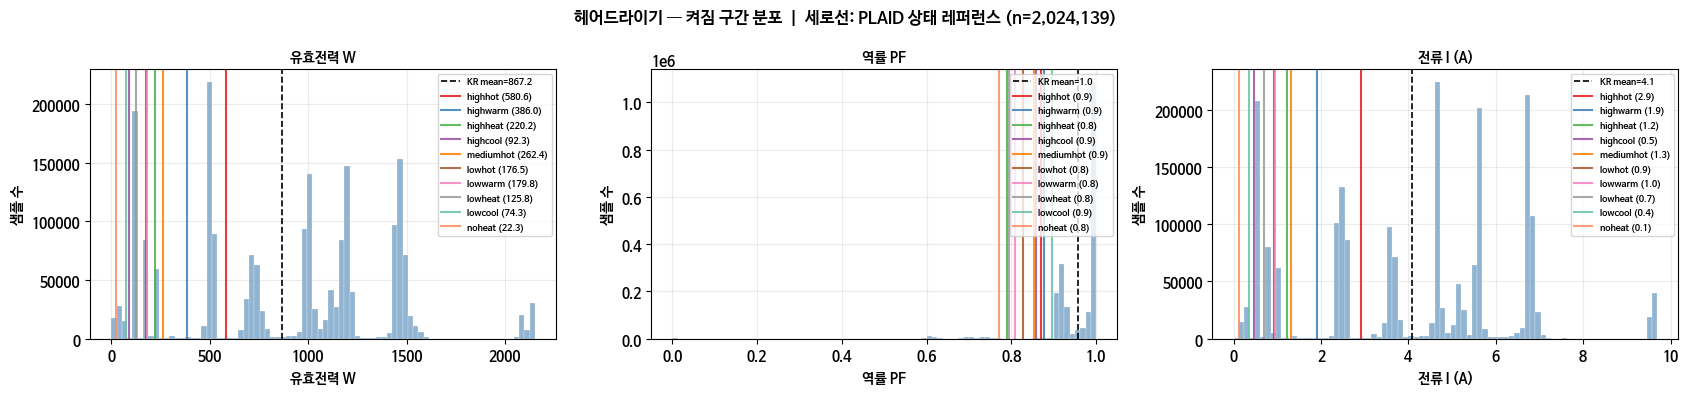

In [13]:
FEATURE_COLS = [
    ('active_power', '유효전력 W',  'W_mean'),
    ('power_factor', '역률 PF',     'PF_mean'),
    ('current',      '전류 I (A)',  'I_mean'),   # PLAID I_mean ÷2 보정 적용
]

for app, df in on_data.items():
    plaid_key = KR_TO_PLAID.get(app)
    plaid = PLAID_STATS.get(plaid_key, {})
    states = list(plaid.keys())

    fig, axes = plt.subplots(1, 3, figsize=(17, 4))
    fig.suptitle(
        f'{app} — 켜짐 구간 분포  |  세로선: PLAID 상태 레퍼런스 (n={len(df):,})',
        fontsize=12, fontweight='bold'
    )

    for ax, (col, label, plaid_field) in zip(axes, FEATURE_COLS):
        if col not in df.columns:
            ax.set_title(f'{label} (컬럼 없음)')
            continue

        vals = df[col].dropna()
        vals = vals[vals <= vals.quantile(0.99)]

        ax.hist(vals, bins=80, color='steelblue', alpha=0.6, edgecolor='white', linewidth=0.3)
        ax.axvline(vals.mean(),   color='black', linestyle='--', linewidth=1.2,
                   label=f'KR mean={vals.mean():.1f}')

        # PLAID 상태별 레퍼런스 라인
        for i, (state, stats) in enumerate(plaid.items()):
            ref_val = stats.get(plaid_field, None)
            if ref_val is None:
                continue
            # 전류는 220V 보정 (÷2)
            if plaid_field == 'I_mean':
                ref_val = ref_val / 2
            color = STATE_COLORS[i % len(STATE_COLORS)]
            ax.axvline(ref_val, color=color, linestyle='-', linewidth=1.5, alpha=0.85,
                       label=f'{state} ({ref_val:.1f})')

        ax.set_title(label, fontsize=10)
        ax.set_xlabel(label)
        ax.set_ylabel('샘플 수')
        ax.legend(fontsize=6.5, loc='upper right')
        ax.grid(True, alpha=0.25)

    plt.tight_layout()
    plt.show()
    print()

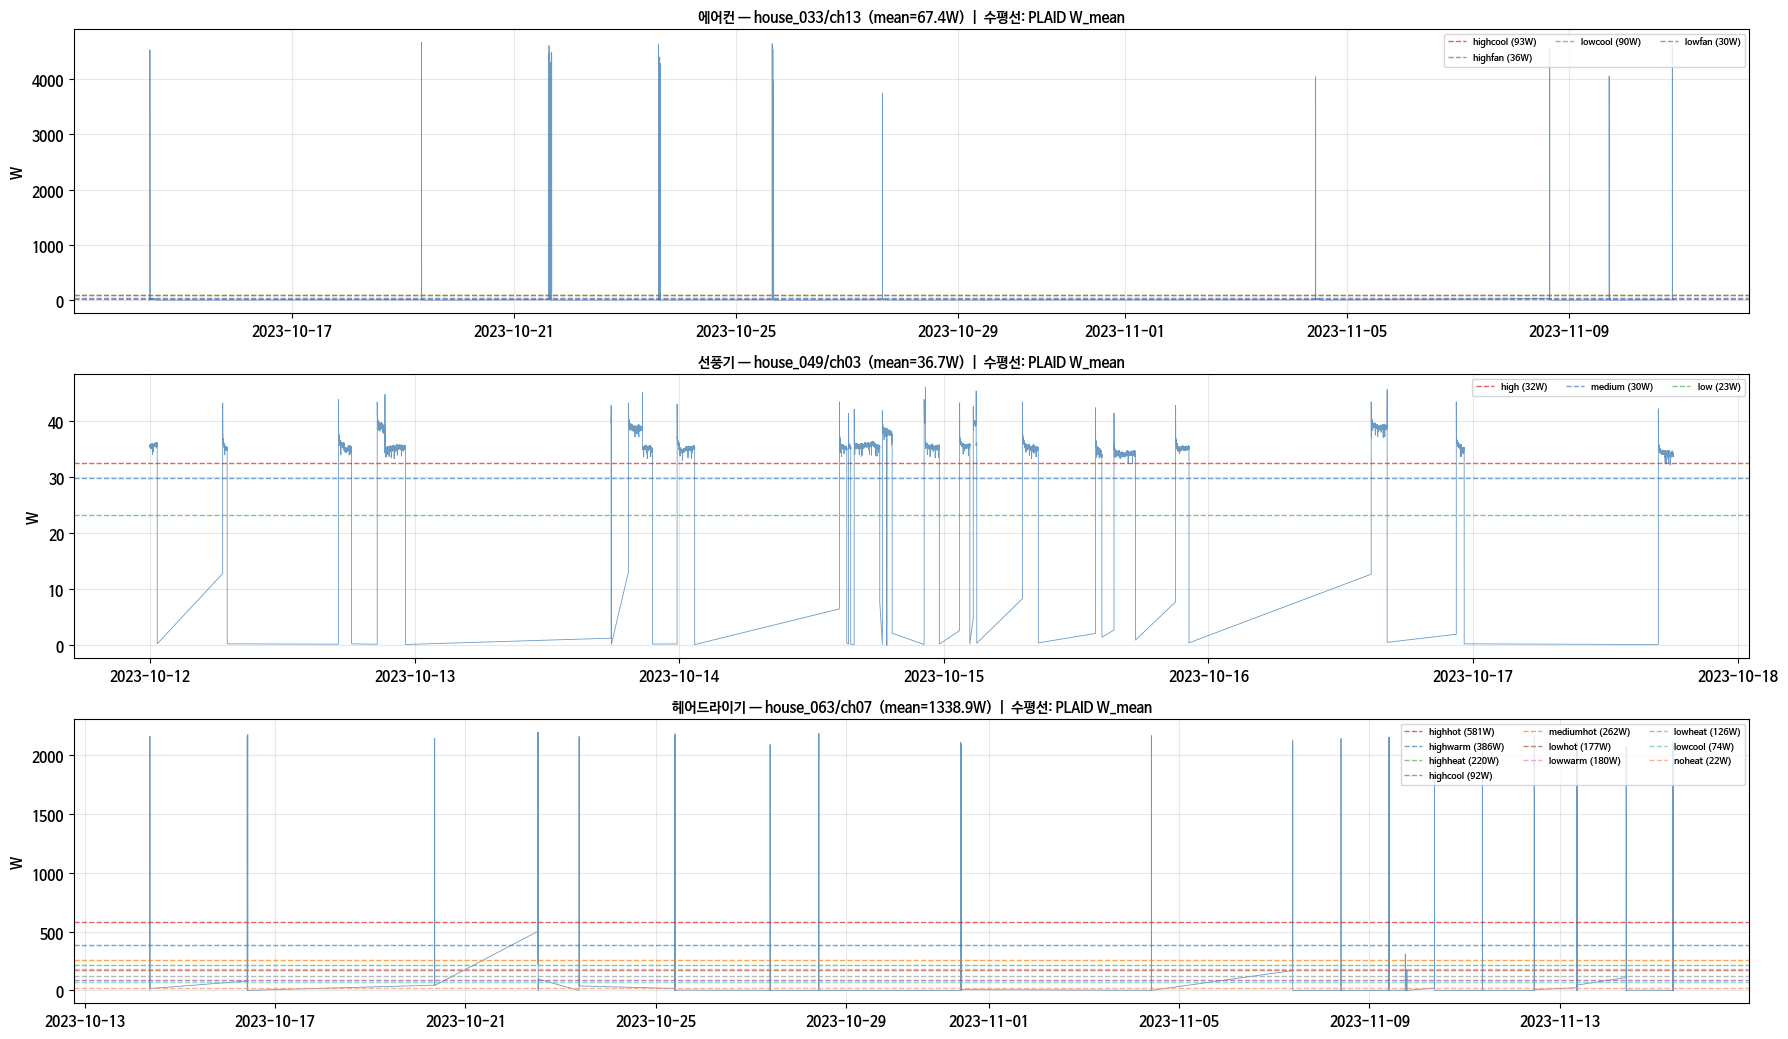

In [14]:
SKIP_APPS = {'전자레인지'}  # on/off 단순 → 시계열 생략

plot_apps = [a for a in TARGET_APPLIANCES if a in on_data and a not in SKIP_APPS]
fig, axes = plt.subplots(len(plot_apps), 1,
                         figsize=(18, 3.5 * len(plot_apps)), sharex=False)
if len(plot_apps) == 1:
    axes = [axes]

for ax, app in zip(axes, plot_apps):
    plaid_key = KR_TO_PLAID.get(app)
    plaid = PLAID_STATS.get(plaid_key, {})
    df = on_data[app].copy()

    # mean W 가장 높은 채널 선택 (품질 기준)
    best_ch = df.groupby('house_channel')['active_power'].mean().idxmax()
    df_ch = df[df['house_channel'] == best_ch].set_index('date_time').sort_index()
    df_plot = df_ch['active_power'].iloc[:24 * 30 * 3600]

    ax.plot(df_plot.index, df_plot.values, linewidth=0.6, color='steelblue', alpha=0.8)

    for i, (state, stats) in enumerate(plaid.items()):
        color = STATE_COLORS[i % len(STATE_COLORS)]
        ax.axhline(stats['W_mean'], color=color, linestyle='--', linewidth=1.0,
                   alpha=0.7, label=f'{state} ({stats["W_mean"]:.0f}W)')

    mean_w = df_ch['active_power'].mean()
    ax.set_title(f'{app} — {best_ch}  (mean={mean_w:.1f}W)  |  수평선: PLAID W_mean', fontsize=10)
    ax.set_ylabel('W')
    ax.legend(fontsize=6.5, loc='upper right', ncol=3)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. 임계값 초안 자동 추정 (valley detection)

히스토그램의 골짜기 위치 + PLAID 레퍼런스를 대조해 최종 임계값을 결정한다.

In [15]:
def suggest_thresholds(app, col='active_power', n_bins=100):
    if app not in on_data:
        print(f'{app} 데이터 없음'); return

    plaid_key = KR_TO_PLAID.get(app)
    plaid = PLAID_STATS.get(plaid_key, {})

    vals = on_data[app][col].dropna()
    vals = vals[vals <= vals.quantile(0.99)]
    counts, bin_edges = np.histogram(vals, bins=n_bins)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    peaks, _ = find_peaks(counts, prominence=counts.max() * 0.1, distance=5)

    print(f'\n[{app}] {col} — 군집 중심 후보:')
    for p in peaks:
        print(f'  KR 피크: {bin_centers[p]:.1f}')

    print(f'  PLAID 레퍼런스:')
    plaid_field = 'W_mean' if col == 'active_power' else ('PF_mean' if col == 'power_factor' else 'I_mean')
    for state, stats in plaid.items():
        ref = stats[plaid_field]
        if plaid_field == 'I_mean': ref /= 2  # 220V 보정
        print(f'    {state}: {ref:.2f}')

    if len(peaks) >= 2:
        print(f'  골짜기 임계값 초안:')
        for i in range(len(peaks) - 1):
            valley_idx = peaks[i] + np.argmin(counts[peaks[i]:peaks[i+1]])
            print(f'    구간 {i+1}|{i+2}: {bin_centers[valley_idx]:.1f}')

for app in TARGET_APPLIANCES:
    suggest_thresholds(app, col='active_power')
    suggest_thresholds(app, col='power_factor')


[에어컨] active_power — 군집 중심 후보:
  KR 피크: 1.9
  KR 피크: 6.1
  KR 피크: 8.5
  KR 피크: 16.2
  KR 피크: 21.6
  KR 피크: 23.1
  KR 피크: 24.9
  KR 피크: 29.3
  PLAID 레퍼런스:
    highcool: 93.05
    highfan: 35.76
    lowcool: 90.40
    lowfan: 29.90
  골짜기 임계값 초안:
    구간 1|2: 3.7
    구간 2|3: 7.6
    구간 3|4: 10.6
    구간 4|5: 19.8
    구간 5|6: 22.2
    구간 6|7: 24.3
    구간 7|8: 28.4

[에어컨] power_factor — 군집 중심 후보:
  KR 피크: 0.1
  KR 피크: 0.1
  KR 피크: 0.2
  KR 피크: 0.3
  KR 피크: 0.6
  KR 피크: 0.6
  PLAID 레퍼런스:
    highcool: 0.78
    highfan: 0.81
    lowcool: 0.76
    lowfan: 0.83
  골짜기 임계값 초안:
    구간 1|2: 0.1
    구간 2|3: 0.2
    구간 3|4: 0.3
    구간 4|5: 0.4
    구간 5|6: 0.6

[선풍기] active_power — 군집 중심 후보:
  KR 피크: 21.1
  KR 피크: 26.2
  KR 피크: 28.5
  KR 피크: 30.9
  KR 피크: 35.2
  PLAID 레퍼런스:
    high: 32.49
    medium: 29.80
    low: 23.18
  골짜기 임계값 초안:
    구간 1|2: 22.6
    구간 2|3: 27.7
    구간 3|4: 29.7
    구간 4|5: 32.9

[선풍기] power_factor — 군집 중심 후보:
  KR 피크: 0.6
  KR 피크: 0.8
  KR 피크: 1.0
  PLAID 레퍼런스:
    high: 0.77
 

## 7. 선풍기 전 채널 시계열 — 속도 전환 패턴 확인

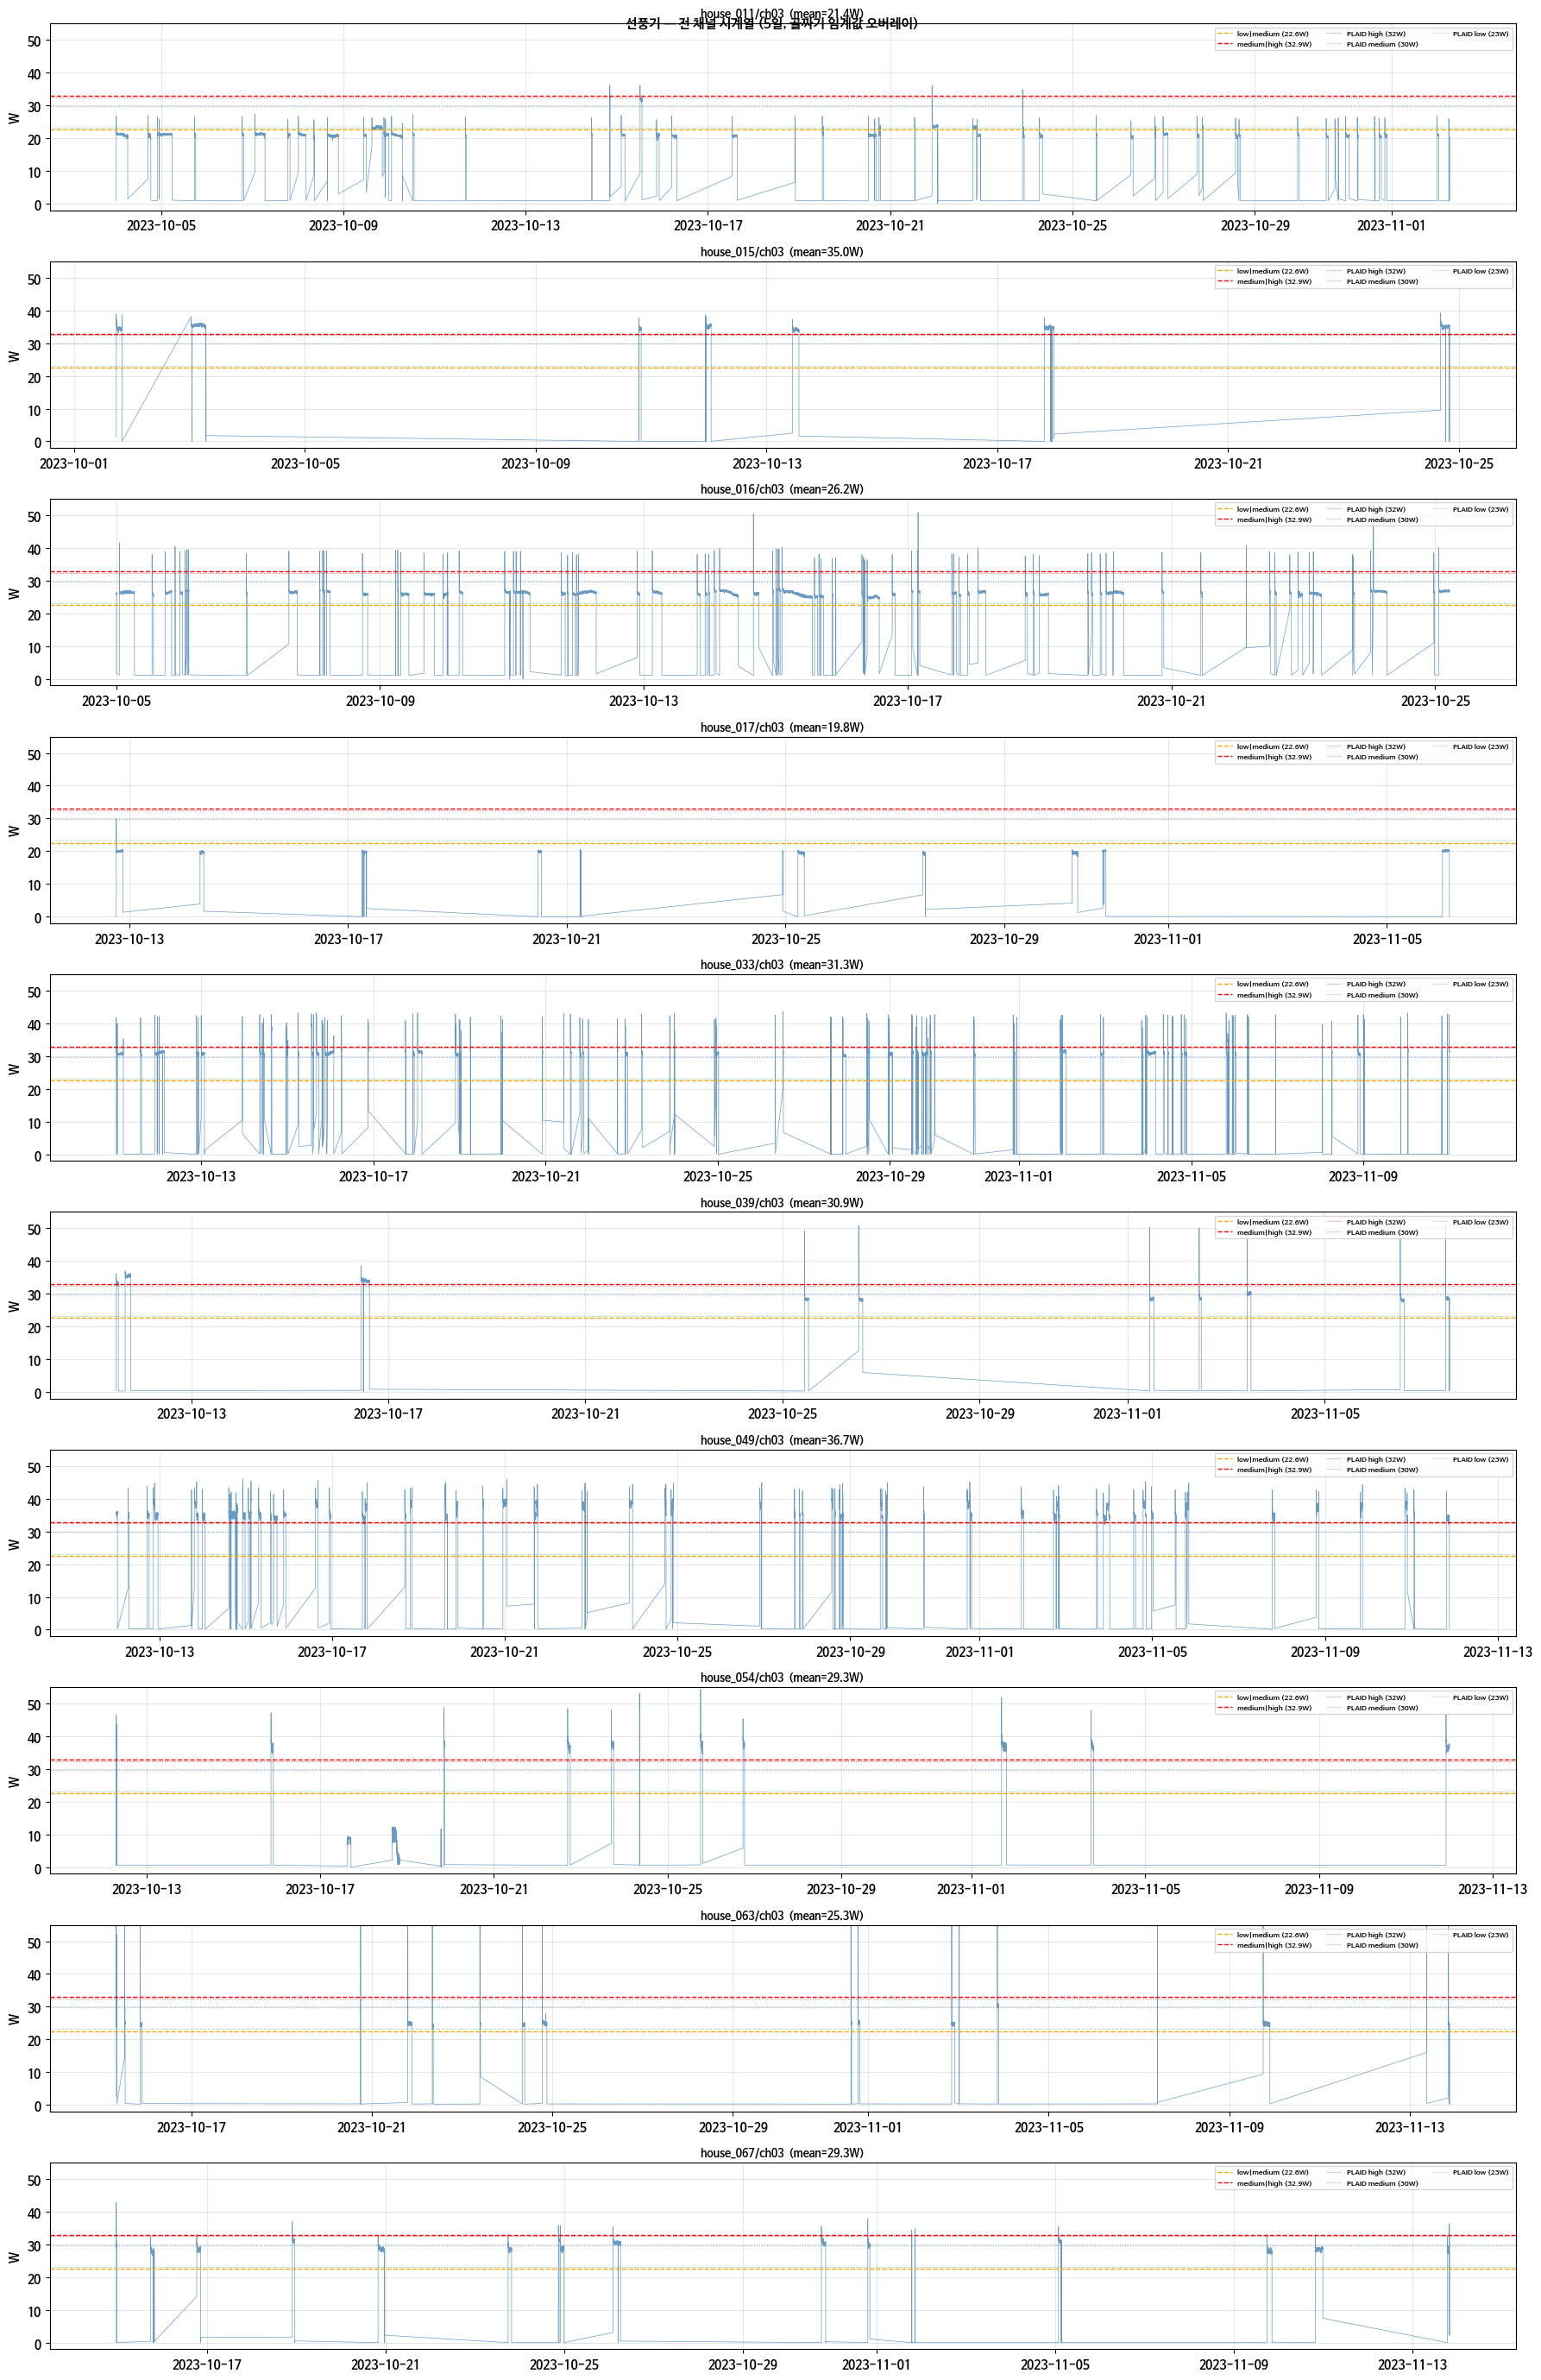

In [16]:
TARGET_CHANNEL_APP = '선풍기'
PLAID_FAN = PLAID_STATS['Fan']

if TARGET_CHANNEL_APP in on_data:
    df = on_data[TARGET_CHANNEL_APP]
    channels = sorted(df['house_channel'].unique())
    fig, axes = plt.subplots(len(channels), 1,
                             figsize=(18, 2.8 * len(channels)), sharex=False)
    if len(channels) == 1:
        axes = [axes]

    for ax, ch in zip(axes, channels):
        df_ch = df[df['house_channel'] == ch].set_index('date_time').sort_index()
        # 5일치만 표시 (전환 패턴 확인용)
        df_plot = df_ch['active_power'].iloc[:5 * 24 * 30 * 3600]
        mean_w = df_ch['active_power'].mean()

        ax.plot(df_plot.index, df_plot.values, linewidth=0.5, color='steelblue', alpha=0.8)
        # 골짜기 임계값
        ax.axhline(22.6, color='orange', linestyle='--', linewidth=1.0, label='low|medium (22.6W)')
        ax.axhline(32.9, color='red',    linestyle='--', linewidth=1.0, label='medium|high (32.9W)')
        for i, (state, stats) in enumerate(PLAID_FAN.items()):
            color = STATE_COLORS[i % len(STATE_COLORS)]
            ax.axhline(stats['W_mean'], color=color, linestyle=':', linewidth=0.8, alpha=0.6,
                       label=f'PLAID {state} ({stats["W_mean"]:.0f}W)')
        ax.set_title(f'{ch}  (mean={mean_w:.1f}W)', fontsize=9)
        ax.set_ylabel('W')
        ax.set_ylim(-2, 55)
        ax.legend(fontsize=6, loc='upper right', ncol=3)
        ax.grid(True, alpha=0.3)

    plt.suptitle('선풍기 — 전 채널 시계열 (5일, 골짜기 임계값 오버레이)', fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.show()
